### Pacotes importados

In [16]:
# codigo aqui

## Chapter 10: Newton's local method

### Algorithm 10.1: Newton's local method

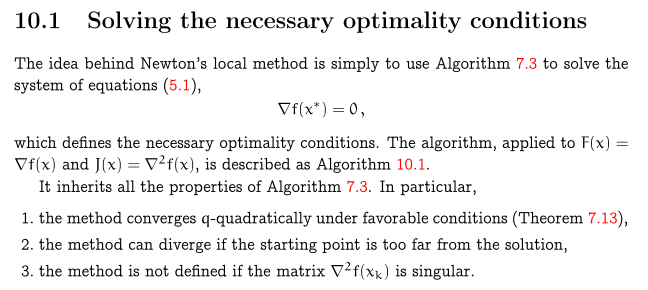

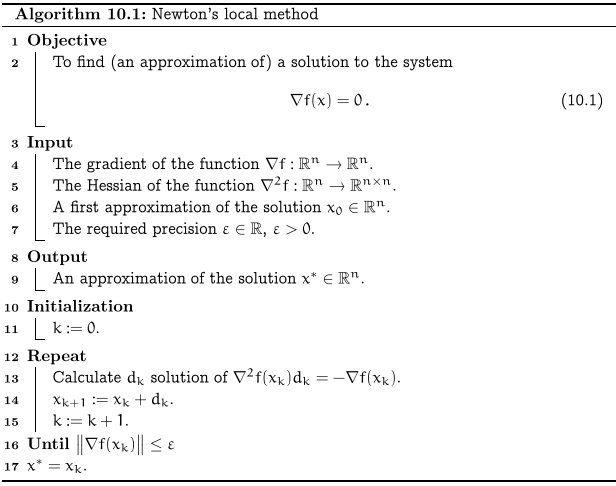

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$; $x_0 = [1.0, 1.0]$

k 	 x1 			 x2 			 ||∇f(xk)|| 	 f(xk)
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +1.75516512E+00 	 +1.04030231E+00
1 	 -2.33845129E-01 	 +1.36419221E+00 	 +2.30665382E-01 	 -2.06286156E-02
2 	 +1.08143753E-02 	 +1.58483641E+00 	 +1.12840545E-02 	 -9.33543995E-05
3 	 -2.13237666E-06 	 +1.57079327E+00 	 +2.32349802E-06 	 -4.24133351E-12
4 	 +1.99048507E-17 	 +1.57079633E+00 	 +8.35430835E-17 	 +1.41692213E-33

x*    = [1.990485074400243e-17, 1.5707963267948966]
f(x*) = 1.4169221291279266e-33
∇f(x*)= [8.113719070137009e-17, -1.990485074400243e-17]


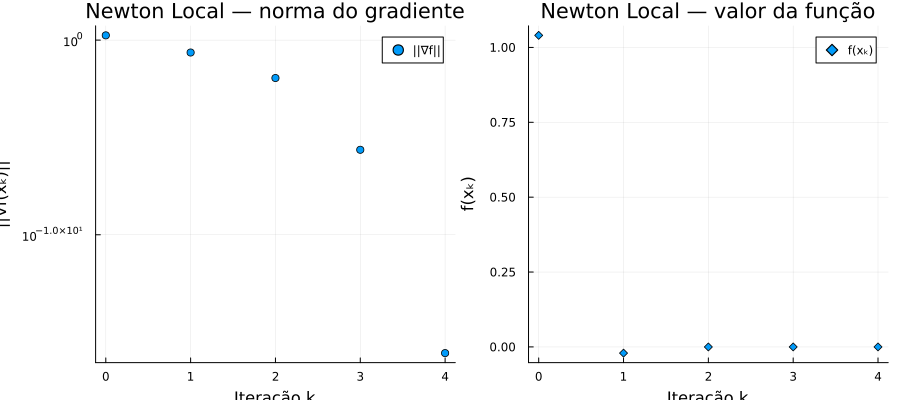

In [17]:
# Algoritmo 10.1 - Método de Newton Local (otimização)
# f(x1, x2) = (1/2)x1² + x1·cos(x2)
# x₀ = [1.0, 1.0], ε = 1e-15

using LinearAlgebra
using Printf
using Plots

# Função objetivo
f(x)  = 0.5 * x[1]^2 + x[1] * cos(x[2])

# Gradiente ∇f
function ∇f(x)
    return [
        x[1] + cos(x[2]),
       -x[1] * sin(x[2])
    ]
end

# Hessiana ∇²f
function ∇²f(x)
    return [
        1.0          -sin(x[2]);
       -sin(x[2])    -x[1]*cos(x[2])
    ]
end

# Parâmetros
x = [1.0, 1.0]
ε = 1e-15
k = 0

ks    = Int[]
norms = Float64[]
fvals = Float64[]

println("k \t x1 \t\t\t x2 \t\t\t ||∇f(xk)|| \t f(xk)")

push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
@printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
        k, x[1], x[2], norm(∇f(x)), f(x))

# Loop principal
while norm(∇f(x)) >= ε

    # Resolver ∇²f(xk) · dk = -∇f(xk)
    d = ∇²f(x) \ (-∇f(x))

    x = x + d
    k += 1

    push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
            k, x[1], x[2], norm(∇f(x)), f(x))
end

println("\nx*    = [", x[1], ", ", x[2], "]")
println("f(x*) = ", f(x))
println("∇f(x*)= ", ∇f(x))

# Gráficos
p1 = plot(ks, norms,
    seriestype = :scatter, marker = :circle,
    xlabel = "Iteração k", ylabel = "||∇f(xₖ)||",
    title = "Newton Local — norma do gradiente",
    yscale = :log10, yformatter = :scientific,
    label = "||∇f||", legend = :topright)

p2 = plot(ks, fvals,
    seriestype = :scatter, marker = :diamond,
    xlabel = "Iteração k", ylabel = "f(xₖ)",
    title = "Newton Local — valor da função",
    label = "f(xₖ)", legend = :topright)

plot(p1, p2, layout = (1,2), size = (900, 400))

### Algorithm 10.2: Newton's local method by quadratic modeling

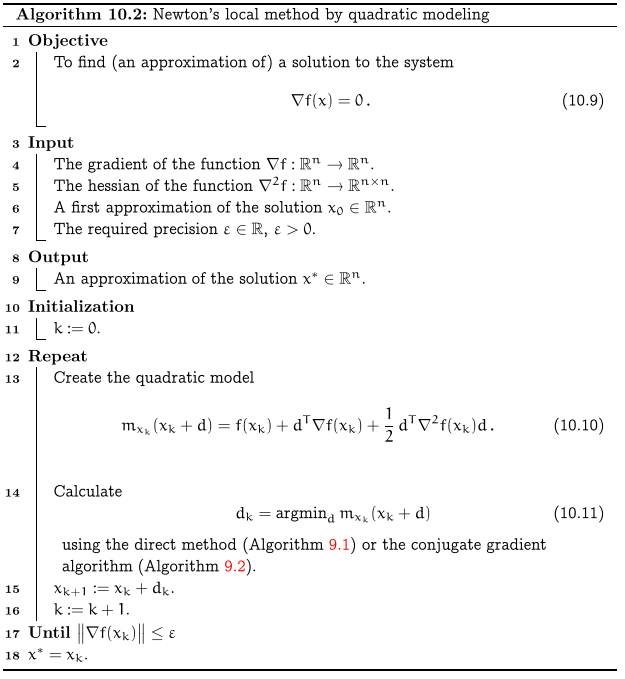

We test the algorithm on the Rosenbrock function. It is described in Section 11.6 of the book for two variables.  The implementation below involves $n$ variables: \\[f(x) = \sum_{i=1}^{n-1} f_i(x) = \sum_{i=1}^{n-1} 100 (x_{i+1}-x_i^2)^2 + (1-x_i)^2.\\]
The calculation of the derivatives is based on the partial derivatives of the functions $f_i$:
\\[
\begin{array}{rcl}
\partial f_i/\partial x_i&=& -400 x_i (x_{i+1}-x_i^2) - 2(1-x_i), \\\\
\partial f_i/\partial x_{i+1}&=& 200 (x_{i+1}-x_i^2), \\\\
\partial^2 f_i/\partial x^2_i  &=& -400 x_{i+1}+ 1200 x_i^2 + 2, \\\\
\partial^2 f_i/\partial x_i \partial x_{i+1}  &=& -400 x_i^2, \\\\
\partial^2 f_i/\partial x^2_{i+1}  &=& 200. 
\end{array}
\\]

Rosenbrock com n = 4 variáveis
x₀ = [-1.0, -1.0, -1.0, -1.0]
f(x₀) = 1212.0

k 	 ||∇f(xk)|| 		 f(xk)
0 	 +1.92500597E+03 	 +1.21200000E+03
1 	 +4.75476240E+02 	 +1.85811929E+02
2 	 +1.71813414E+02 	 +6.29039936E+01
3 	 +2.06985403E+01 	 +4.31659651E+00
4 	 +2.65810209E+00 	 +3.40745592E+00
5 	 +2.62314541E+04 	 +2.90965532E+04
6 	 +7.70995994E+03 	 +5.65565828E+03
7 	 +2.22461713E+03 	 +1.01579443E+03
8 	 +4.35119717E+03 	 +2.82324102E+03
9 	 +1.25370297E+03 	 +5.10820574E+02
10 	 +2.88052900E+02 	 +8.97057766E+01
⋮
20 	 +2.94684217E-12 	 +5.34805786E-27

x*    = [1.0, 1.0, 1.0, 1.0]
f(x*) = 5.3480578550425614e-27
Solução esperada: x* = [1, 1, ..., 1],  f(x*) = 0
Erro ||x* - 1|| = 1.7655687952576088e-14


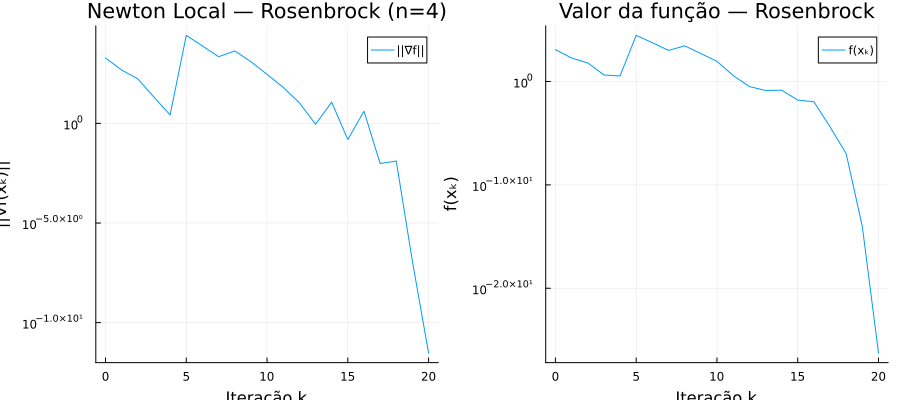

In [18]:
# Algoritmo 10.2 - Newton's Local Method by Quadratic Modeling
# Função de Rosenbrock com n variáveis
# f(x) = Σᵢ₌₁ⁿ⁻¹ 100(x_{i+1} - xᵢ²)² + (1 - xᵢ)²

using LinearAlgebra
using Printf
using Plots

# ── Função de Rosenbrock ─────────────────────────────────────────────────
function f(x)
    n = length(x)
    return sum(100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2 for i in 1:n-1)
end

# ── Gradiente ∇f ─────────────────────────────────────────────────────────
function ∇f(x)
    n  = length(x)
    g  = zeros(n)
    for i in 1:n-1
        g[i]   += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])  # ∂fᵢ/∂xᵢ
        g[i+1] +=  200*(x[i+1] - x[i]^2)                        # ∂fᵢ/∂x_{i+1}
    end
    return g
end

# ── Hessiana ∇²f (esparsa, tridiagonal) ──────────────────────────────────
function ∇²f(x)
    n = length(x)
    H = zeros(n, n)
    for i in 1:n-1
        H[i,   i]   += -400*x[i+1] + 1200*x[i]^2 + 2   # ∂²fᵢ/∂xᵢ²
        H[i,   i+1] += -400*x[i]                         # ∂²fᵢ/∂xᵢ∂x_{i+1}
        H[i+1, i]   += -400*x[i]                         # simetria
        H[i+1, i+1] +=  200.0                             # ∂²fᵢ/∂x²_{i+1}
    end
    return H
end

# ── Parâmetros ────────────────────────────────────────────────────────────
n   = 4
x   = -ones(n)     # x₀ = [-1, -1, ..., -1]  (clássico para Rosenbrock)
ε   = 1e-10
k   = 0
maxiter = 1000

ks    = Int[]
norms = Float64[]
fvals = Float64[]

println("Rosenbrock com n = $n variáveis")
println("x₀ = ", x)
println("f(x₀) = ", f(x))
println()
println("k \t ||∇f(xk)|| \t\t f(xk)")

push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
@printf("%d \t %+.8E \t %+.8E\n", k, norm(∇f(x)), f(x))

# ── Loop principal ────────────────────────────────────────────────────────
while norm(∇f(x)) >= ε && k < maxiter

    H = ∇²f(x)
    g = ∇f(x)

    # Verificar se H é P.D. (condição para mínimo do modelo quadrático)
    # Se não for, usar gradiente descendente como fallback
    local d
    try
        # Resolver ∇²f(xk)·dk = -∇f(xk)  (Alg. 9.1 via Cholesky)
        C = cholesky(Symmetric(H))
        d = C \ (-g)
    catch
        # Fallback: direção de gradiente negativo
        d = -g / norm(g)
    end

    x = x + d
    k += 1

    push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))

    if k <= 10 || k % 50 == 0
        @printf("%d \t %+.8E \t %+.8E\n", k, norm(∇f(x)), f(x))
    end
end

println("⋮")
@printf("%d \t %+.8E \t %+.8E\n", k, norm(∇f(x)), f(x))
println("\nx*    = ", round.(x, digits=8))
println("f(x*) = ", f(x))
println("Solução esperada: x* = [1, 1, ..., 1],  f(x*) = 0")
println("Erro ||x* - 1|| = ", norm(x .- 1))

# ── Gráficos ──────────────────────────────────────────────────────────────
p1 = plot(ks, norms,
    seriestype  = :line,
    xlabel      = "Iteração k",
    ylabel      = "||∇f(xₖ)||",
    title       = "Newton Local — Rosenbrock (n=$n)",
    yscale      = :log10,
    yformatter  = :scientific,
    label       = "||∇f||",
    legend      = :topright)

p2 = plot(ks, fvals,
    seriestype  = :line,
    xlabel      = "Iteração k",
    ylabel      = "f(xₖ)",
    title       = "Valor da função — Rosenbrock",
    yscale      = :log10,
    yformatter  = :scientific,
    label       = "f(xₖ)",
    legend      = :topright)

plot(p1, p2, layout = (1,2), size = (900, 400))

We now apply the algorithm on example 5.8. In this case, the algorithm fails to converge, and one hessian is not positive definite. We try first using the direct method to solve the quadratic problem. An error is triggered. 

In [19]:
# Algoritmo 10.2 - Newton's Local Method by Quadratic Modeling
# Exemplo 5.8: f(x1, x2) = (1/2)x1² + x1·cos(x2)
# x₀ = [1.0, 1.0] — Hessiana NÃO é P.D. em geral → erro esperado

using LinearAlgebra
using Printf
using Plots

# ── Funções ───────────────────────────────────────────────────────────────
f(x)  = 0.5 * x[1]^2 + x[1] * cos(x[2])

function ∇f(x)
    return [
        x[1] + cos(x[2]),
       -x[1] * sin(x[2])
    ]
end

function ∇²f(x)
    return [
        1.0          -sin(x[2]);
       -sin(x[2])    -x[1]*cos(x[2])
    ]
end

# ── Parâmetros ────────────────────────────────────────────────────────────
x   = [1.0, 1.0]
ε   = 1e-15
k   = 0
maxiter = 50

ks    = Int[]
norms = Float64[]
fvals = Float64[]

println("=== Algoritmo 10.2 — Método Direto (Cholesky) ===")
println("f(x1,x2) = (1/2)x1² + x1·cos(x2),  x₀ = [1.0, 1.0]\n")
println("k \t x1 \t\t\t x2 \t\t\t ||∇f|| \t\t f(xk)")

push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
@printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
        k, x[1], x[2], norm(∇f(x)), f(x))

# ── Loop principal ────────────────────────────────────────────────────────
convergiu = false

while norm(∇f(x)) >= ε && k < maxiter

    H = ∇²f(x)
    g = ∇f(x)

    # Diagnóstico da Hessiana a cada iteração
    eigenvalues = eigvals(Symmetric(H))
    is_pd       = all(eigenvalues .> 0)

    println("\n--- Iteração k = $k ---")
    @printf("  H = [ %+.6f  %+.6f ]\n", H[1,1], H[1,2])
    @printf("      [ %+.6f  %+.6f ]\n", H[2,1], H[2,2])
    @printf("  Autovalores: λ1 = %+.6E,  λ2 = %+.6E\n",
            eigenvalues[1], eigenvalues[2])
    println("  H é P.D.? ", is_pd ? "✓ SIM" : "✗ NÃO")

    # Tentativa com Cholesky (Alg. 9.1) — ERRO se H não P.D.
    try
        C = cholesky(Symmetric(H))
        d = C \ (-g)
        x = x + d
        k += 1
        push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
        @printf("\n%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
                k, x[1], x[2], norm(∇f(x)), f(x))

        if norm(∇f(x)) < ε
            convergiu = true
            break
        end

    catch e
        println("\n✗ ERRO na fatoração de Cholesky na iteração k=$k:")
        println("  ", e)
        println("\n  Causa: ∇²f(xk) não é positiva definida.")
        println("  O modelo quadrático m(xk+d) não tem mínimo finito.")
        println("  O método direto (Alg. 9.1) não pode ser aplicado.")
        println("\n  → Algoritmo interrompido.")
        break
    end
end

if convergiu
    println("\n✓ Convergiu!")
    println("x*    = [", x[1], ", ", x[2], "]")
    println("f(x*) = ", f(x))
else
    println("\n⚠️  O algoritmo NÃO convergiu com o método direto (Cholesky).")
    println("   Último iterado: x = [", x[1], ", ", x[2], "]")
    println("   ||∇f|| = ", norm(∇f(x)))
end

# ── Gráfico (iterações que completaram) ───────────────────────────────────
if length(ks) > 1
    p1 = plot(ks, norms,
        seriestype = :scatter, marker = :circle,
        xlabel = "Iteração k", ylabel = "||∇f(xₖ)||",
        title = "Newton Quadrático — Exemplo 5.8",
        yscale = :log10, yformatter = :scientific,
        label = "||∇f||", legend = :topright)

    p2 = plot(ks, fvals,
        seriestype = :scatter, marker = :diamond,
        xlabel = "Iteração k", ylabel = "f(xₖ)",
        title = "Valor da função — Exemplo 5.8",
        label = "f(xₖ)", legend = :topright)

    plot(p1, p2, layout = (1,2), size = (900, 400))
end

=== Algoritmo 10.2 — Método Direto (Cholesky) ===
f(x1,x2) = (1/2)x1² + x1·cos(x2),  x₀ = [1.0, 1.0]

k 	 x1 			 x2 			 ||∇f|| 		 f(xk)
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +1.75516512E+00 	 +1.04030231E+00

--- Iteração k = 0 ---
  H = [ +1.000000  -0.841471 ]
      [ -0.841471  -0.540302 ]
  Autovalores: λ1 = -9.108554E-01,  λ2 = +1.370553E+00
  H é P.D.? ✗ NÃO

✗ ERRO na fatoração de Cholesky na iteração k=0:
  PosDefException(2)

  Causa: ∇²f(xk) não é positiva definida.
  O modelo quadrático m(xk+d) não tem mínimo finito.
  O método direto (Alg. 9.1) não pode ser aplicado.

  → Algoritmo interrompido.

⚠️  O algoritmo NÃO convergiu com o método direto (Cholesky).
   Último iterado: x = [1.0, 1.0]
   ||∇f|| = 1.7551651237807455


If we try with the conjugate gradient method, an error is also triggered. 

In [20]:
# Algoritmo 10.2 - Newton's Local Method by Quadratic Modeling
# Exemplo 5.8: f(x1, x2) = (1/2)x1² + x1·cos(x2)
# x₀ = [1.0, 1.0] — usando Gradiente Conjugado (Alg. 9.2) como subrotina

using LinearAlgebra
using Printf
using Plots

# ── Funções ───────────────────────────────────────────────────────────────
f(x)  = 0.5 * x[1]^2 + x[1] * cos(x[2])

function ∇f(x)
    return [
        x[1] + cos(x[2]),
       -x[1] * sin(x[2])
    ]
end

function ∇²f(x)
    return [
        1.0          -sin(x[2]);
       -sin(x[2])    -x[1]*cos(x[2])
    ]
end

# ── Subrotina: Gradiente Conjugado (Alg. 9.2) ────────────────────────────
# Resolve min (1/2)dᵀQd + gᵀd  →  Qd = -g
# Q = ∇²f(xk),  g = ∇f(xk)
function gradiente_conjugado(Q, g; ε_cg=1e-14, maxiter=100)
    n  = length(g)
    d  = zeros(n)          # solução inicial d = 0
    r  = -Q * d - (-g)     # r₁ = -g - Q·0 = -g  →  direção inicial
    p  = copy(r)           # p₁ = r₁
    k  = 1

    println("  [CG] Iniciando Gradiente Conjugado para subproblema quadrático")
    println("  [CG] Q = ∇²f(xk):")
    @printf("       [ %+.6f  %+.6f ]\n", Q[1,1], Q[1,2])
    @printf("       [ %+.6f  %+.6f ]\n", Q[2,1], Q[2,2])

    eigs = eigvals(Symmetric(Q))
    @printf("  [CG] Autovalores de Q: λ1 = %+.6E,  λ2 = %+.6E\n",
            eigs[1], eigs[2])
    println("  [CG] Q é P.D.? ", all(eigs .> 0) ? "✓ SIM" : "✗ NÃO")
    println()

    while norm(r) > ε_cg && k <= maxiter

        pQp = p' * Q * p     # pᵀQp — deve ser > 0 se Q P.D.

        @printf("  [CG] k=%d: ||r|| = %+.6E,  pᵀQp = %+.6E", k, norm(r), pQp)

        if pQp <= 0
            println("  ← ✗ pᵀQp ≤ 0 — Q não é P.D.!")
            println("\n  ✗ ERRO no Gradiente Conjugado:")
            println("    pᵀQp = $(pQp) ≤ 0 na iteração k=$k do subproblema.")
            println("    Q = ∇²f(xk) é indefinida → subproblema sem mínimo finito.")
            println("    O Gradiente Conjugado não pode minimizar o modelo quadrático.")
            return nothing, true   # retorna flag de erro
        end

        println()   # linha normal se pQp > 0

        α  = (r' * r) / pQp
        d  = d + α * p
        r_new = r - α * Q * p
        β  = (r_new' * r_new) / (r' * r)
        p  = r_new + β * p
        r  = r_new
        k += 1
    end

    return d, false   # retorna solução e flag sem erro
end

# ── Parâmetros ────────────────────────────────────────────────────────────
x       = [1.0, 1.0]
ε       = 1e-15
k       = 0
maxiter = 50

ks    = Int[]
norms = Float64[]
fvals = Float64[]

println("=== Algoritmo 10.2 — Gradiente Conjugado como subrotina ===")
println("f(x1,x2) = (1/2)x1² + x1·cos(x2),  x₀ = [1.0, 1.0]\n")
println("k \t x1 \t\t\t x2 \t\t\t ||∇f|| \t\t f(xk)")

push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
@printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
        k, x[1], x[2], norm(∇f(x)), f(x))

convergiu = false

while norm(∇f(x)) >= ε && k < maxiter

    H = ∇²f(x)
    g = ∇f(x)

    println("\n--- Iteração k = $k ---")

    # Subrotina: Gradiente Conjugado para resolver H·d = -g
    d, erro = gradiente_conjugado(H, g)

    if erro
        println("\n⚠️  O Gradiente Conjugado falhou na iteração k=$k.")
        println("   Causa raiz: ∇²f(xk) não é positiva definida.")
        println("   Nem o método direto (Cholesky) nem o Gradiente Conjugado")
        println("   conseguem resolver o subproblema quadrático.")
        println("   → Algoritmo 10.2 interrompido.")
        break
    end

    x = x + d
    k += 1

    push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
    @printf("\n%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
            k, x[1], x[2], norm(∇f(x)), f(x))

    if norm(∇f(x)) < ε
        convergiu = true
        break
    end
end

if convergiu
    println("\n✓ Convergiu!  x* = [", x[1], ", ", x[2], "]")
else
    println("\n⚠️  Algoritmo 10.2 NÃO convergiu com nenhum dos dois subsolvers.")
    println("   Próximo passo: usar modificação da Hessiana (Alg. 10.3) ou")
    println("   método globalizado (região de confiança / line search).")
end

=== Algoritmo 10.2 — Gradiente Conjugado como subrotina ===
f(x1,x2) = (1/2)x1² + x1·cos(x2),  x₀ = [1.0, 1.0]

k 	 x1 			 x2 			 ||∇f|| 		 f(xk)
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +1.75516512E+00 	 +1.04030231E+00

--- Iteração k = 0 ---
  [CG] Iniciando Gradiente Conjugado para subproblema quadrático
  [CG] Q = ∇²f(xk):
       [ +1.000000  -0.841471 ]
       [ -0.841471  -0.540302 ]
  [CG] Autovalores de Q: λ1 = -9.108554E-01,  λ2 = +1.370553E+00
  [CG] Q é P.D.? ✗ NÃO

  [CG] k=1: ||r|| = +1.755165E+00,  pᵀQp = +4.171252E+00
  [CG] k=2: ||r|| = +2.507085E-01,  pᵀQp = -5.794993E-02  ← ✗ pᵀQp ≤ 0 — Q não é P.D.!

  ✗ ERRO no Gradiente Conjugado:
    pᵀQp = -0.057949929287297225 ≤ 0 na iteração k=2 do subproblema.
    Q = ∇²f(xk) é indefinida → subproblema sem mínimo finito.
    O Gradiente Conjugado não pode minimizar o modelo quadrático.

⚠️  O Gradiente Conjugado falhou na iteração k=0.
   Causa raiz: ∇²f(xk) não é positiva definida.
   Nem o método direto (Cholesky) nem o Grad